# Resampling of the Topographic Dataset (GMTED2010)
This section describes the preprocessing of the GMTED2010 topographic dataset to a 25 km spatial resolution to ensure consistency with the ΔT<sub>b</sub> dataset used in the SHAP analysis.

The original dataset, provided as 1 km GeoTIFF files, was first converted to NetCDF format and subsequently resampled to a 25 km grid.

In [1]:
import sys
import os
import platform
import importlib
import math
import glob
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import calendar
import netCDF4 as nc
import xarray as xr
from datetime import timedelta
import datetime
from dateutil.relativedelta import relativedelta
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Proj, transform
import cartopy.feature as cfeature
import matplotlib.path as mpath
import rioxarray
import rasterio
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
import geopandas as gpd
from shapely.geometry import Point
from scipy.stats import linregress, spearmanr
from pymannkendall import original_test
import matplotlib.colors as mcolors
from scipy.stats import kendalltau


if platform.system() == 'Darwin':  # macOS
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
else:
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
sys.path.append(base_FP + '/python_modules')

# HydroAI libs
import HydroAI.Data as hData
import HydroAI.Plot as hPlot
import HydroAI.Grid as hGrid
import HydroAI.Land_Properties as hLP
importlib.reload(hData);
importlib.reload(hPlot);
importlib.reload(hGrid);
importlib.reload(hLP);

# Ignore runtime warnings
import warnings
warnings.filterwarnings("ignore")

## Create the land mask for regions north of 60°N

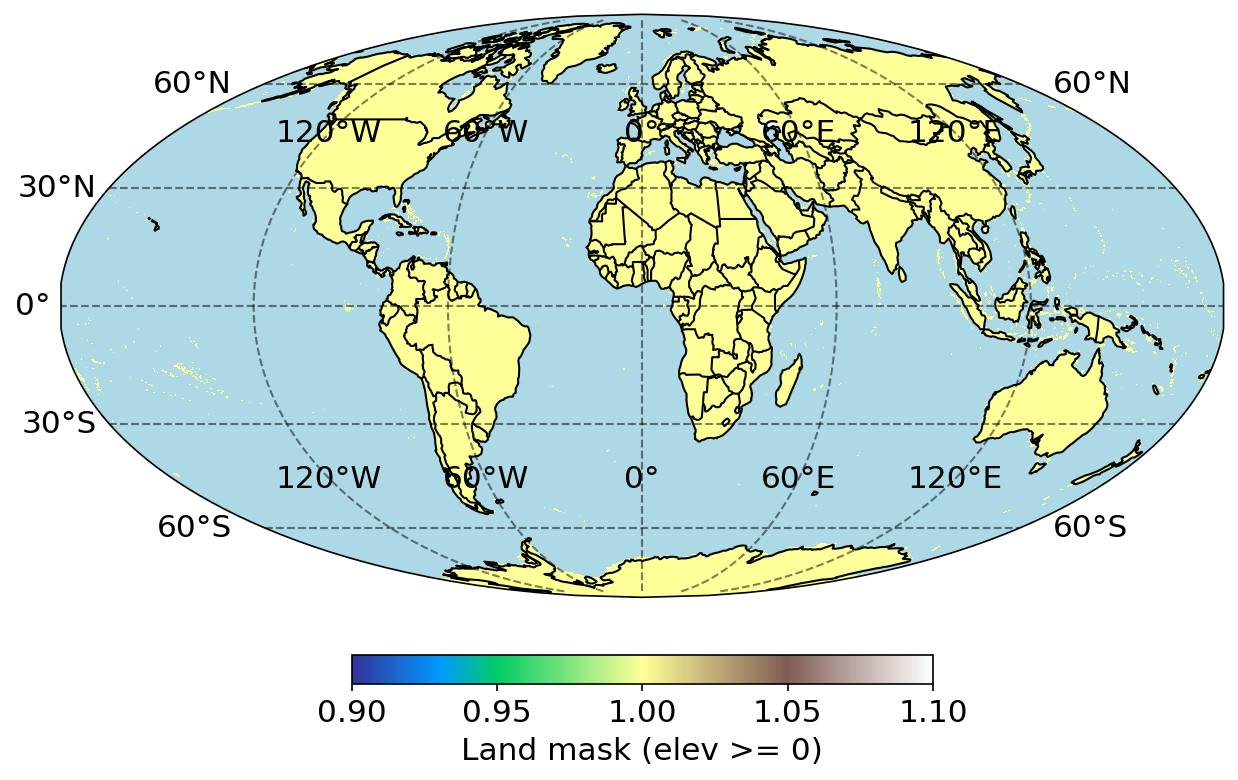

In [2]:
# Create land mask using DEM
domain_lon, domain_lat = hGrid.generate_lon_lat_eqdgrid(0.25)

DEM_path = '/home/nayoung/nas_data/DEM'
Find_DEM_File = sorted(glob.glob(os.path.join(DEM_path, "*.nc")))
DEM_25km = nc.Dataset(Find_DEM_File[0])
with nc.Dataset(Find_DEM_File[0]) as ds:
    DEM_elev = ds.variables['elev'][:]      # (lat, lon)
    lat  = ds.variables['lat'][:]       # (lat,)
    lon  = ds.variables['lon'][:]       # (lon,)

land_mask = DEM_elev > 0
land_only = np.where(land_mask, 1, np.nan)

# Check the land mask for the entire world
hPlot.plot_map(domain_lon, domain_lat, land_only, np.nanmin(land_only), 1, plot_title="Land mask (elev >= 0)", label_title="Land mask (elev >= 0)", cmap='terrain')

# Extract the pixels in the range of 60N~90N
lat_mask_idx = np.where(lat >= 60)[0]

# Cut the pixels in the range of 60N~90N
elev_np = DEM_elev.filled(np.nan)  
elev_60N = elev_np[lat_mask_idx, :]

land_mask_60N_base = np.isfinite(elev_60N).astype(np.uint8) 

## Define functions to plot for the north of 60°N

In [3]:
def plot_Northpole(domain_lon, domain_lat, data, label_title, cmap,
                   vmin=-1, vmax=1, vcenter=0, bounds=None, ticks=None, ticklabels=None):

    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor='powderblue', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)

    masked_data = np.ma.masked_invalid(data)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(alpha=0)

    # Continuous/Discrete norm
    if bounds is None:
        if vcenter is None:
            norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        else:
            norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    else:
        norm = mcolors.BoundaryNorm(bounds, ncolors=cmap_obj.N, clip=True)

    mesh = ax.pcolormesh(
        domain_lon, domain_lat, masked_data,
        transform=ccrs.PlateCarree(),
        cmap=cmap_obj,
        norm=norm,
        zorder=2,
        shading="auto"
    )

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle='--', zorder=4)
                
    gl.xlabel_style = {'size': 18}
    gl.ylabel_style = {'size': 18}

    gl.top_labels = False
    gl.right_labels = False

    cbar = plt.colorbar(
        mesh, ax=ax, orientation='horizontal',
        pad=0.07, shrink=0.8, extend='neither',
        boundaries=bounds if bounds is not None else None,
        ticks=ticks
    )
    cbar.set_label(label_title, fontsize=12, labelpad=10)
    cbar.ax.tick_params(labelsize=18)

    if ticklabels is not None:
        cbar.set_ticklabels(ticklabels)
    elif bounds is None:
        tick_values = np.linspace(vmin, vmax, 5)
        cbar.set_ticks(tick_values)
        cbar.set_ticklabels([f'{v:.2f}' for v in tick_values])

    plt.title(label_title, fontsize=16, pad=20)
    plt.show()

    return fig, ax

### Convert GeoTIFF files into NetCDF format

In [4]:
# Define paths
GMTED_tif_file_path = '/home/nayoung/nas_data/DEM/GMTED2010'
GMTED_nc_file_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/GMTED2010'
os.makedirs(GMTED_nc_file_path, exist_ok=True)

# Only variables that are needed
GMTED_keep_vars_list = ["elevation", "slope", "aspectcosine"]

# Convert each TIFF to NC
for file in os.listdir(GMTED_tif_file_path):
    if not file.endswith('.tif'):
        continue

    # Extract variable name from file
    var_name = file.split("_")[0]

    # Skip if not in keep list
    if var_name not in GMTED_keep_vars_list:
        continue

    tif_file_path = os.path.join(GMTED_tif_file_path, file)

    with rasterio.open(tif_file_path) as src:
        data = src.read(1)
        transform = src.transform
        lon = np.arange(src.width) * transform[0] + transform[2]
        lat = np.arange(src.height) * transform[4] + transform[5]

    # Output NetCDF file
    nc_filename = os.path.splitext(file)[0] + ".nc"
    nc_file_path = os.path.join(GMTED_nc_file_path, nc_filename)

    with nc.Dataset(nc_file_path, "w") as dst:
        dst.createDimension("lat", len(lat))
        dst.createDimension("lon", len(lon))

        lat_var = dst.createVariable("lat", "f4", ("lat",))
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        data_var = dst.createVariable(var_name, "f4", ("lat", "lon",))

        lat_var[:] = lat
        lon_var[:] = lon
        data_var[:, :] = data

    print(f"Saved: {var_name}")

Saved: elevation
Saved: slope
Saved: aspectcosine


### Resample from 1km to 25km resolution

In [5]:
# Define paths
GMTED_nc_file_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/GMTED2010'
GMTED_above60N_path = os.path.join(GMTED_nc_file_path, "Above_60N")
os.makedirs(GMTED_above60N_path, exist_ok=True)

domain_lon, domain_lat = hGrid.generate_lon_lat_eqdgrid(0.25)

for file in os.listdir(GMTED_nc_file_path):
    if not file.endswith('.nc'):
        continue
    if file.endswith('_60N.nc'):
        continue  # Skip already processed files

    nc_file_path = os.path.join(GMTED_nc_file_path, file)

    with nc.Dataset(nc_file_path) as ds:
        lat = ds.variables['lat'][:]
        lon = ds.variables['lon'][:]
        var_name = file.split("_")[0]
        data = ds.variables[var_name][:]
        print(f"The shape of the original {var_name} data:", np.shape(data))

    # Create 2D lon/lat
    lon_2d, lat_2d = np.meshgrid(lon, lat)

    # Resample to 25 km
    data_25km = hData.Resampling(
        domain_lon, domain_lat,
        lon_2d, lat_2d,
        data, 'nearest', 'mean',
        mag_factor=2
    )

    # Extract regions north of 60°N
    row_idx = np.where(domain_lat[:, 0] >= 60)[0]
    data_25km_60N = data_25km[row_idx, :]

    # Apply land mask
    data_25km_60N = np.where(land_mask_60N_base, data_25km_60N, np.nan)

    print(f"The shape of the resampled {var_name} data:", np.shape(data_25km_60N))

    # Save to Above_60N folder
    out_path = os.path.join(GMTED_above60N_path, file.replace('.nc', '_25km_60N.nc'))
    with nc.Dataset(out_path, "w") as dst:
        lat_1d = domain_lat[row_idx, 0]
        lon_1d = domain_lon[0, :]

        dst.createDimension("lat", len(lat_1d))
        dst.createDimension("lon", len(lon_1d))

        lat_var = dst.createVariable("lat", "f4", ("lat",))
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        data_var = dst.createVariable(var_name, "f4", ("lat", "lon",))

        lat_var[:] = lat_1d
        lon_var[:] = lon_1d
        data_var[:, :] = data_25km_60N

    print(f"Saved: {out_path}")

The shape of the original aspectcosine data: (16800, 43200)
The shape of the resampled aspectcosine data: (120, 1440)
Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/GMTED2010/Above_60N/aspectcosine_1KMmd_GMTEDmd_25km_60N.nc
The shape of the original slope data: (16800, 43200)
The shape of the resampled slope data: (120, 1440)
Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/GMTED2010/Above_60N/slope_1KMmd_GMTEDmd_25km_60N.nc
The shape of the original elevation data: (16800, 43200)
The shape of the resampled elevation data: (120, 1440)
Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/GMTED2010/Above_60N/elevation_1KMmd_GMTEDmd_25km_60N.nc


## Verify that the resampled GMTED2010 dataset was generated correctly

In [12]:
def plot_gmted(data, title):
    fig, ax = plt.subplots(figsize=(10, 10))
    cmap = plt.cm.get_cmap('terrain', 20) 
    
    im = ax.imshow(data, cmap=cmap)
    ax.set_title(title)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1) 
    
    plt.colorbar(im, cax=cax, label=None)
    plt.show()

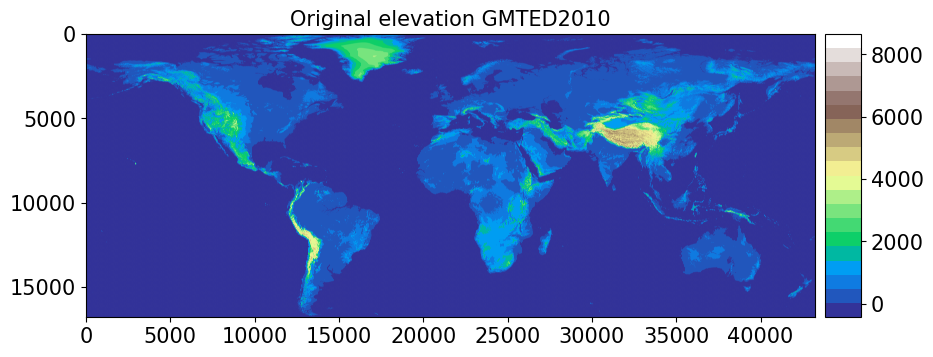

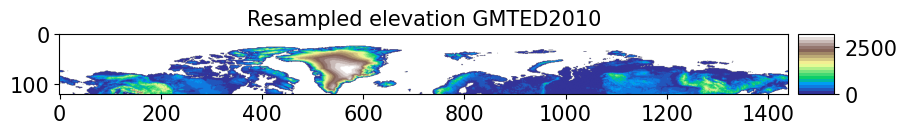

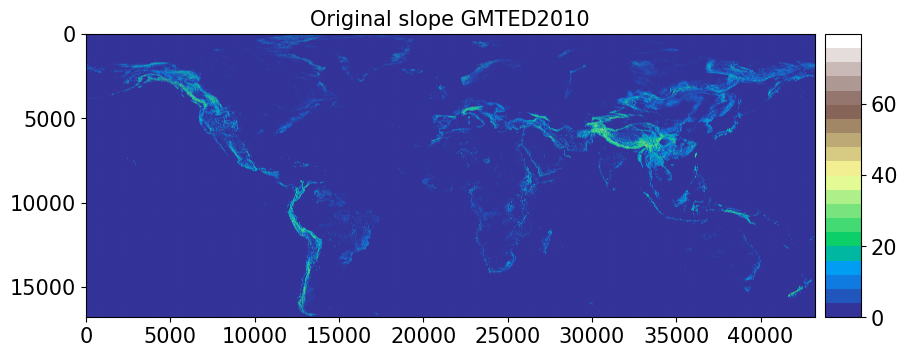

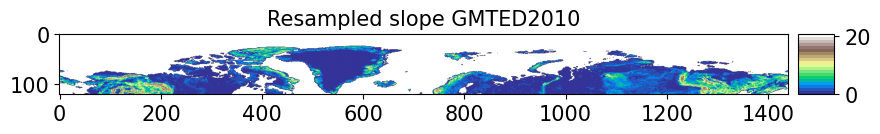

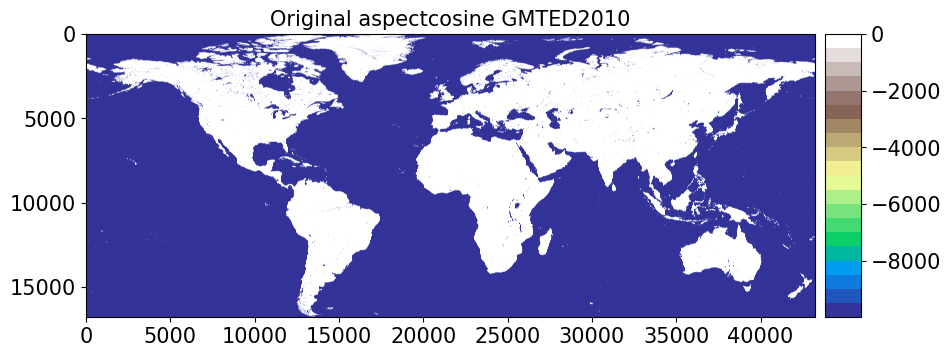

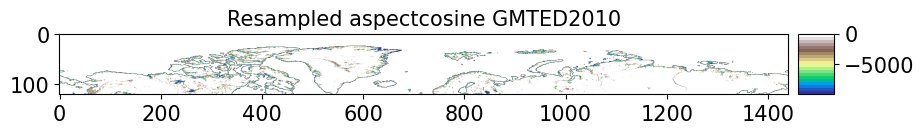

In [16]:
# Compare for the same variable
variable_list = ['elevation', 'slope', 'aspectcosine']

for variable in variable_list:
    Original_GMTED_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/GMTED2010/{variable}_1KMmd_GMTEDmd.nc'
    Resampled_GMTED_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/GMTED2010/Above_60N/{variable}_1KMmd_GMTEDmd_25km_60N.nc'

    # Load the original GMTED2010 data
    with nc.Dataset(Original_GMTED_path) as ds:
        lat = ds.variables['lat'][:]
        lon = ds.variables['lon'][:]
        Original_GMTED = ds.variables[variable][:]

    # Load the resampled GMTED2010 data
    with nc.Dataset(Resampled_GMTED_path) as ds:
        lat = ds.variables['lat'][:]
        lon = ds.variables['lon'][:]
        Resampled_GMTED = ds.variables[variable][:]

    # Compare the two datasets (Due to the high memory requirements of the original 1km resolution data, generating the NorthPole plot is not feasible in this case)
    plot_gmted(Original_GMTED, f'Original {variable} GMTED2010')
    plot_gmted(Resampled_GMTED, f'Resampled {variable} GMTED2010')